--------------------------------------------------
ANALYSE FRAGE 4: MwSt-Effekt vs. Inflation
------------------------------
Preisentwicklung während MwSt-Senkung (H2 2020): -1.35%
Preisentwicklung Inflationsjahr 2021:          14.07%
--------------------------------------------------
ERGEBNIS:
Die Händler haben die MwSt-Senkung 2020 teilweise an die Kunden weitergegeben (Preise sanken).
Der Effekt wurde durch die Inflation 2021 (14.07%) komplett neutralisiert.
--------------------------------------------------


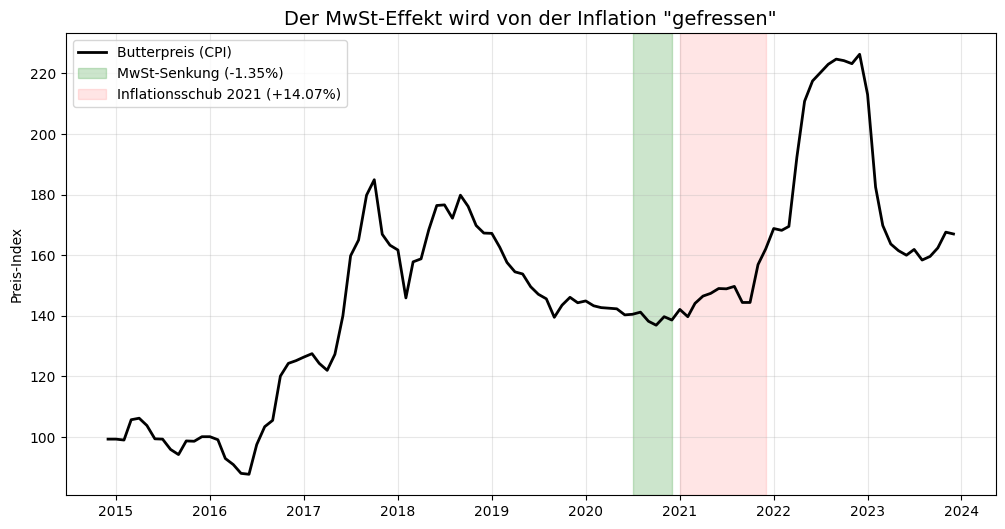

In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. FUNKTION (Standard für Eurostat/Destatis JSON)
def eurostat_json_to_df(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    time_index = data['dimension']['time']['category']['index'] 
    time_labels = data['dimension']['time']['category']['label'] 
    values = data['value'] 
    rows = []
    for label_key, position in time_index.items():
        pos_str = str(position)
        if pos_str in values:
            rows.append({'datum': time_labels[label_key], 'preis': values[pos_str]})
    df = pd.DataFrame(rows)
    df['datum'] = pd.to_datetime(df['datum'].str.replace('M', '-'), format='%Y-%m')
    return df.sort_values('datum')

# 2. DATEN LADEN (Kombination von 2 Datenquellen)
df_butter = eurostat_json_to_df('eurostat_butter_cpi.json').rename(columns={'preis': 'butter_cpi'})
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json').rename(columns={'preis': 'dairy_ppi'})

# Zusammenführen
df_vat = pd.merge(df_butter, df_ppi, on='datum', how='inner')

# 3. POLICY DUMMY ERSTELLEN (Manuelle "API"-Erweiterung)
# 1 = MwSt gesenkt (Juli 2020 bis Dez 2020), 0 = Normal
df_vat['mwst_dummy'] = 0
df_vat.loc[(df_vat['datum'] >= '2020-07-01') & (df_vat['datum'] <= '2020-12-31'), 'mwst_dummy'] = 1

# 4. ANALYSE DER PHASEN
# Phase A: MwSt-Senkung (Hälfte 2 2020)
v_2020_start = df_vat[df_vat['datum'] == '2020-07-01']['butter_cpi'].values[0]
v_2020_end = df_vat[df_vat['datum'] == '2020-12-01']['butter_cpi'].values[0]
vat_effect = ((v_2020_end - v_2020_start) / v_2020_start) * 100

# Phase B: Inflationsschub 2021 (Ganzes Jahr)
v_2021_start = df_vat[df_vat['datum'] == '2021-01-01']['butter_cpi'].values[0]
v_2021_end = df_vat[df_vat['datum'] == '2021-12-01']['butter_cpi'].values[0]
inflation_2021 = ((v_2021_end - v_2021_start) / v_2021_start) * 100

# 5. ANTWORT PRINTEN
print("-" * 50)
print("ANALYSE FRAGE 4: MwSt-Effekt vs. Inflation")
print("-" * 30)
print(f"Preisentwicklung während MwSt-Senkung (H2 2020): {vat_effect:.2f}%")
print(f"Preisentwicklung Inflationsjahr 2021:          {inflation_2021:.2f}%")
print("-" * 50)

print("ERGEBNIS:")
if vat_effect < 0:
    print("Die Händler haben die MwSt-Senkung 2020 teilweise an die Kunden weitergegeben (Preise sanken).")
else:
    print("Die MwSt-Senkung kam im Ladenpreis kaum an.")

print(f"Der Effekt wurde durch die Inflation 2021 ({inflation_2021:.2f}%) " + 
      ("komplett" if inflation_2021 > abs(vat_effect) else "teilweise") + " neutralisiert.")
print("-" * 50)

import matplotlib.pyplot as plt
import plotly.express as px

# --- 1. STATISCHE GRAFIK (Matplotlib) ---
plt.figure(figsize=(12, 6))

# Preisverlauf
plt.plot(df_vat['datum'], df_vat['butter_cpi'], color='black', lw=2, label='Butterpreis (CPI)')

# Markierung der MwSt-Senkung (Juli - Dez 2020)
plt.axvspan('2020-07-01', '2020-12-01', color='green', alpha=0.2, label='MwSt-Senkung (-1.35%)')

# Markierung des Inflationsjahres 2021
plt.axvspan('2021-01-01', '2021-12-01', color='red', alpha=0.1, label='Inflationsschub 2021 (+14.07%)')

plt.title('Der MwSt-Effekt wird von der Inflation "gefressen"', fontsize=14)
plt.ylabel('Preis-Index')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. INTERAKTIVE GRAFIK (4 von 7) ---
fig4 = px.line(df_vat, x='datum', y='butter_cpi', 
               title='Interaktive Analyse: MwSt-Senkung vs. Inflationswelle',
               labels={'butter_cpi': 'Butterpreis Index', 'datum': 'Zeitpunkt'})

# Highlight-Bereiche hinzufügen
fig4.add_vrect(x0="2020-07-01", x1="2020-12-31", fillcolor="green", opacity=0.2, 
               annotation_text="MwSt-Senkung", annotation_position="top left")
fig4.add_vrect(x0="2021-01-01", x1="2021-12-31", fillcolor="red", opacity=0.1, 
               annotation_text="Inflation 2021", annotation_position="top left")

fig4.show()